# Data Visualization

Note: the visualization scripts in this notebook uses the statistical summary data


### Imports


In [1]:
%pip install pandas matplotlib scipy
import os
import json
import pandas as pd

import analysis_utils as utils


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load data from all `../res` sub-directories (treatments):


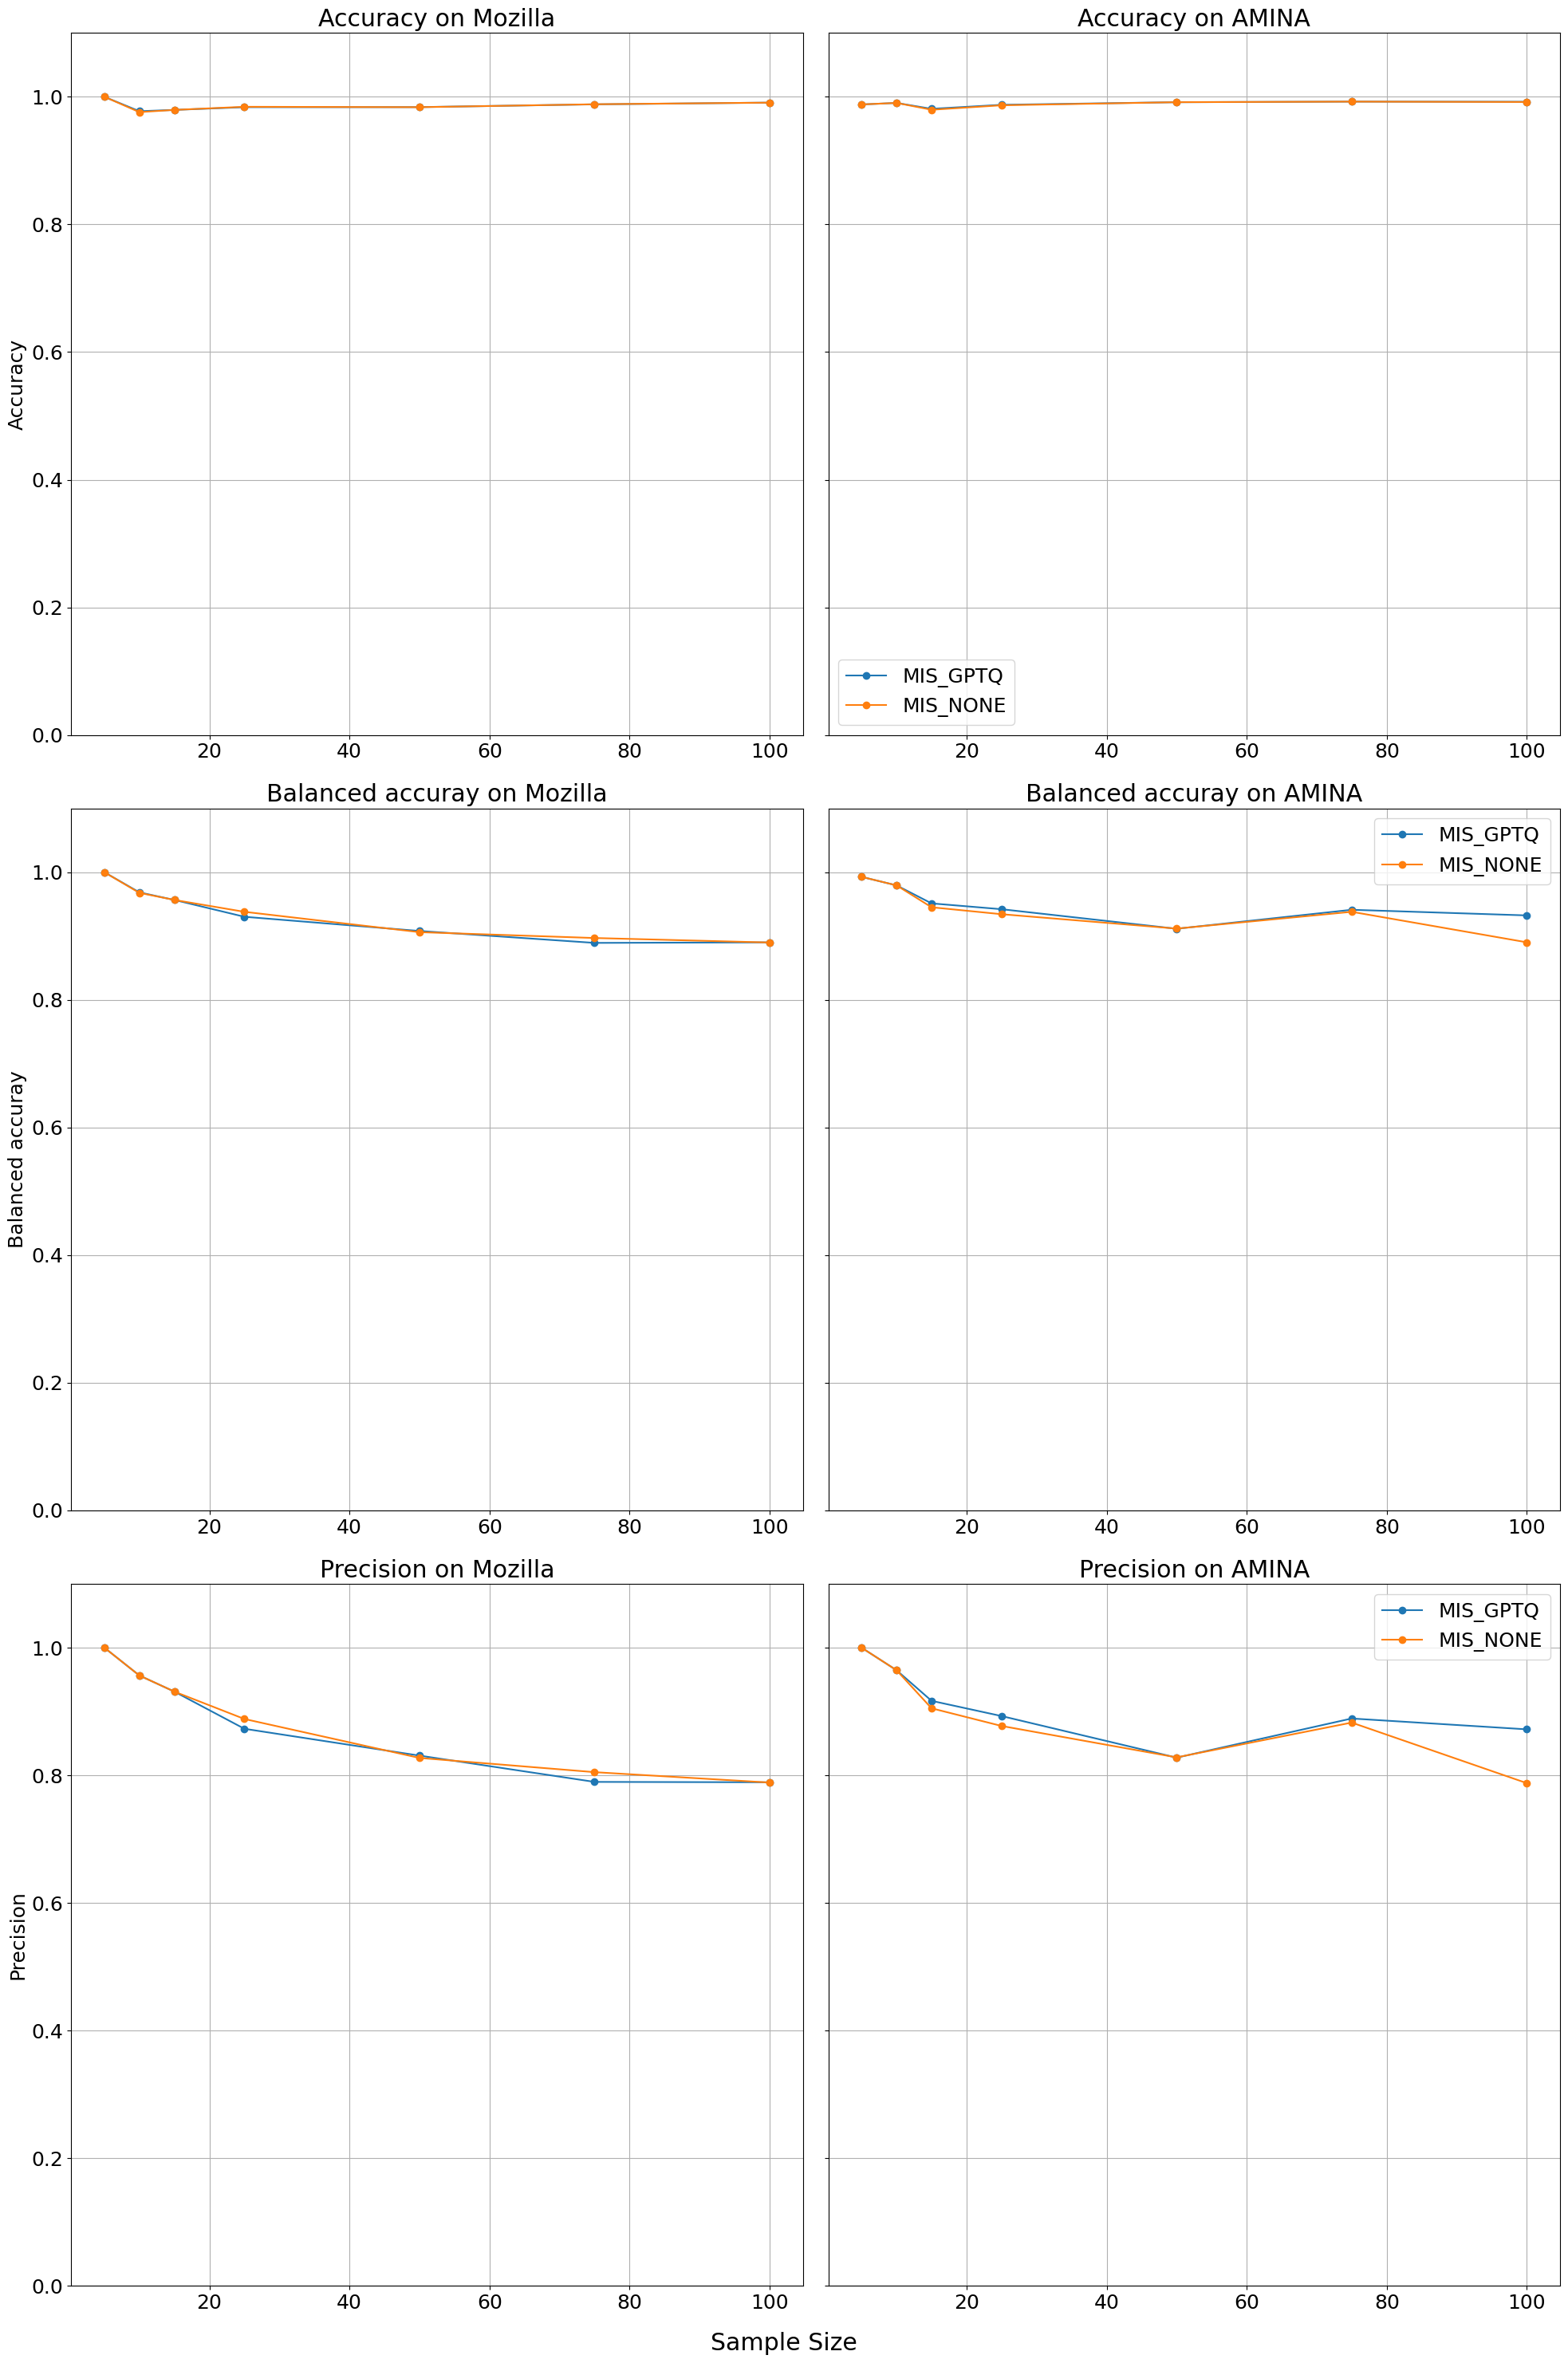

In [30]:
import numpy as np
import matplotlib.pyplot as plt

summary_dfs = {}    # dict to store statistical summary data (<session_name>.json)
all_data_dfs = {}   # dict to store all individual measurements (all_data_<session_name>.json)

experiment_data_dir = '../res' # directory generated by "eval.py", contains the .json files with the experiment data

iteration_structure = True # flag to set the directory structure of the input data

# Load all the experiment data
summary_dfs, all_data_dfs, _ = utils.load_experiment_data(experiment_data_dir, iteration_structure)

plt.rcParams.update({
    'font.size': 18  # Adjust the number to your desired base size
})

# TODO: avoid hard-coding this
sample_sizes = [5, 10, 15, 25, 50, 75, 100]

options = ['MIS_GPTQ_Mozilla', 'MIS_NONE_Mozilla', 'MIS_GPTQ_AMINA', 'MIS_NONE_AMINA']

keys = [
    # ("time_to_analyze", "Inference time (s)"),
    ("accuracy", None),
    ("balanced_accuracy", "Balanced accuray"),
    # ("recall", None),
    ("precision", None),
    # ("f1", "F1-score")
]

# keys = list(all_data_dfs[list(all_data_dfs.keys())[0]].keys())[1:]

models = ["MIS_GPTQ", "MIS_NONE"]
datasets = ["AMINA", "Mozilla"]

# Create 1 row, 2 columns of subplots, sharing y-axis
fig, axes = plt.subplots(nrows=len(keys), ncols=2, figsize=(20, 30), sharey='row')

for i, (k, label) in enumerate(keys):
    data: list[str, list[int] | list[float]] = {
        'Sample Size': sample_sizes,
        **{k:[] for k in options}
    }

    for model in models:
        for dataset in datasets:
            for sample in sample_sizes:
                key: str = f"{model}_{dataset}-{sample}"
                t = np.mean(all_data_dfs[key][k])
                data[f"{model}_{dataset}"].append(t)
    # print(df)    
    df = pd.DataFrame(data)
    
    # Calculate global max y-value for consistent y-axis limits
    y_max = df[df.columns[1:5]].max().max()
    
    for method in df.columns[1:3]:
        axes[i][0].plot(df['Sample Size'], df[method], marker='o', label=method.replace("_Mozilla", ""))
        
    axes[i,0].set_title(f'{k.capitalize() if label is None else label} on Mozilla')
    axes[i,0].set_ylabel(k.capitalize() if label is None else label)
    axes[i,0].grid(True)
    axes[i,0].set_ylim(0, y_max * 1.1)    

    for method in df.columns[3:5]:
        axes[i][1].plot(df['Sample Size'], df[method], marker='o', label=method.replace("_AMINA", ""))
    axes[i][1].set_title(f'{k.capitalize() if label is None else label} on AMINA')
    axes[i][1].grid(True)
    axes[i][1].set_ylim(0, y_max * 1.1)
    axes[i][1].legend()
    fig.supxlabel('Sample Size')
    
    data = {} # reset
    
fig.tight_layout()
fig.savefig(f"out/RQ3_excerpt.svg", format='svg')

Linearithmic Fit R^2: 0.9656
Exponential Fit R^2: 0.9467
Linearithmic Fit R^2: 0.9655
Exponential Fit R^2: 0.9406
Linearithmic Fit R^2: 0.9825
Exponential Fit R^2: 0.9473
Linearithmic Fit R^2: 0.9840
Exponential Fit R^2: 0.9302


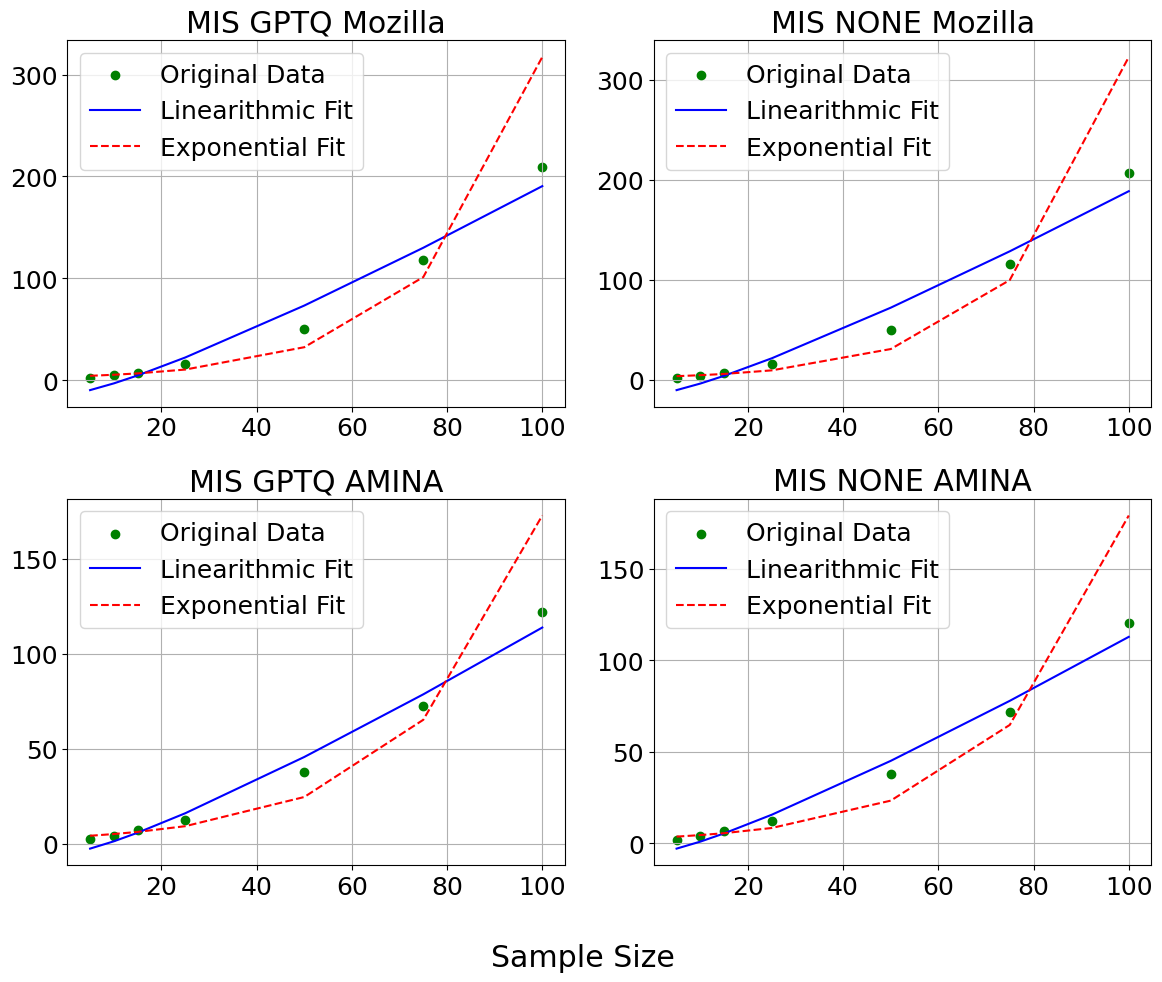

In [24]:
from scipy.stats import linregress


# List of 4 datasets (x, y) pairs
datasets = [
    (opt, np.array(data[opt]), np.array(sample_sizes)) for opt in options
]

# Create a 2x2 plot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()  # Flatten to simplify indexing

# Collect all y and fitted y values from the datasets to find global min and max
all_y_values = []
for (_, y, x) in datasets:
    ln_y = np.log(y)
    slope, intercept, _, _, _ = linregress(x, ln_y)
    y_pred = np.exp(intercept + slope * x)
    all_y_values.extend(y)
    all_y_values.extend(y_pred)

# Determine global y-limits
ymin = min(all_y_values)
ymax = max(all_y_values)

for i, (dataset, y, x) in enumerate(datasets):
    # Linearithmic
    z = x * np.log(x)
    slope_linlog, intercept_linlog, r_value_linlog, _, _ = linregress(z, y)
    y_pred_linlog = slope_linlog * z + intercept_linlog
    
    # Optional: Compare to exponential fit
    ln_y = np.log(y)
    slope_exp, intercept_exp, r_value_exp, _, _ = linregress(x, ln_y)
    y_pred_exp = np.exp(intercept_exp + slope_exp * x)

    # Print R^2 scores
    print(f"Linearithmic Fit R^2: {r_value_linlog**2:.4f}")
    print(f"Exponential Fit R^2: {r_value_exp**2:.4f}")

    # Plotting
    ax = axs[i]
    ax.scatter(x, y, label='Original Data', color='green')
    ax.plot(x, y_pred_linlog, label='Linearithmic Fit', color='blue')
    ax.plot(x, y_pred_exp, label='Exponential Fit', color='red', linestyle='--')
    ax.set_title(dataset.replace("_", " "))
    # ax.set_ylim(ymin, ymax)
    ax.legend()
    ax.grid(True)

fig.supxlabel('Sample Size')
plt.tight_layout()
plt.savefig("RQ3_linear_regression.svg", format='svg')
plt.show()